# Qual é o melhor plano?

Você trabalha como analista para a empresa de telecomunicações Megaline. A empresa oferece aos clientes dois planos pré-pagos: Surf e Ultimate. O departamento comercial quer saber qual dos planos gera mais receita para ajustar o orçamento de publicidade.

Você vai realizar uma análise preliminar dos planos com base em uma pequena seleção de clientes. Você terá dados de 500 clientes da Megaline: que clientes são, de onde eles são, qual plano usam e o número de chamadas e mensagens realizadas em 2018. Seu trabalho é analisar o comportamento dos clientes e determinar qual plano pré-pago gera mais receita.

[Fornecemos alguns comentários para guiar sua linha de raciocínio enquanto você trabalha neste projeto. Entretanto, certifique-se de remover todos os comentários entre colchetes antes de enviar o projeto.]

[Antes de começar a análise dos dados, explique com suas próprias palavras o propósito do projeto e as ações que planeja realizar.]

[Tenha em mente que estudar, modificar e analisar dados é um processo iterativo. É normal retornar a etapas anteriores e corrigir/expandir algo para permitir as próximas etapas.]

Analisar e comparar os planos entre si, juntamente com a quantidade de dados e valores correlacionados!

## Inicialização

In [1]:
import pandas as pd


## Carregue os dados

In [2]:


import pandas as pd

users = pd.read_csv('/datasets/megaline_users.csv')
plans = pd.read_csv('/datasets/megaline_plans.csv')
calls = pd.read_csv('/datasets/megaline_calls.csv')
internet = pd.read_csv('/datasets/megaline_internet.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')


## Prepare os dados

[Os dados deste projeto estão divididos em várias tabelas. Explore cada uma para obter uma compreensão inicial dos dados. Faça correções em cada tabela, se necessário.]

## Planos

In [3]:

plans.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [4]:
plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


[Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?]

Os dados estão limpos e consistentes 

## Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

Nada a ser corrigido 

In [8]:
print('Nulos por coluna:\n', plans.isna().sum())
print('\nDuplicatas:', plans.duplicated().sum())
print('\nDtypes:\n', plans.dtypes)

Nulos por coluna:
 messages_included        0
mb_per_month_included    0
minutes_included         0
usd_monthly_pay          0
usd_per_gb               0
usd_per_message          0
usd_per_minute           0
plan_name                0
dtype: int64

Duplicatas: 0

Dtypes:
 messages_included          int64
mb_per_month_included      int64
minutes_included           int64
usd_monthly_pay            int64
usd_per_gb                 int64
usd_per_message          float64
usd_per_minute           float64
plan_name                 object
dtype: object


## Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [9]:

import pandas as pd
from pandas.api.types import is_datetime64_any_dtype as is_dt


if not is_dt(calls['call_date']):
    calls['call_date'] = pd.to_datetime(calls['call_date'], errors='coerce')

if not is_dt(messages['message_date']):

    messages['message_date'] = pd.to_datetime(messages['message_date'], errors='coerce')

if not is_dt(internet['session_date']):
    internet['session_date'] = pd.to_datetime(internet['session_date'], errors='coerce')


calls['month']    = calls['call_date'].dt.month
messages['month'] = messages['message_date'].dt.month
internet['month'] = internet['session_date'].dt.month


calls['user_month']    = calls['user_id'].astype(str) + '_' + calls['month'].astype(str)
messages['user_month'] = messages['user_id'].astype(str) + '_' + messages['month'].astype(str)
internet['user_month'] = internet['user_id'].astype(str) + '_' + internet['month'].astype(str)


print(calls[['call_date','month']].head())
print(messages[['message_date','month']].head())
print(internet[['session_date','month']].head())






   call_date  month
0 2018-12-27     12
1 2018-12-27     12
2 2018-12-27     12
3 2018-12-28     12
4 2018-12-30     12
  message_date  month
0   2018-12-27     12
1   2018-12-31     12
2   2018-12-31     12
3   2018-12-27     12
4   2018-12-26     12
  session_date  month
0   2018-12-29     12
1   2018-12-31     12
2   2018-12-28     12
3   2018-12-26     12
4   2018-12-27     12


## Usuários

In [10]:
users.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [11]:
users.head()



,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


[Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?]

O único ajuste necessário é converter as colunas reg_date e churn_date para o formato datetime

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [ ]:

users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
users['churn_date'] = pd.to_datetime(users['churn_date'], errors='coerce')


users.info()


### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [ ]:
import pandas as pd


users['reg_month'] = users['reg_date'].dt.month
users['reg_year'] = users['reg_date'].dt.year


users['is_active'] = users['churn_date'].isna()


users['days_active'] = (users['churn_date'] - users['reg_date']).dt.days


users.head()


## Chamadas

In [ ]:
calls.info()




In [ ]:


calls.head()



[Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?]

In [ ]:
Os dados estão limpos e consistentes.
A única observação é que chamadas com duração igual a 0 minutos não devem ser contabilizadas em análises de uso.

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [ ]:
calls = calls[calls['duration'] > 0]

calls.head()


### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [13]:
import numpy as np


calls['duration'] = np.ceil(calls['duration'])


calls = calls[calls['duration'] > 0]


print(calls['duration'].describe())
calls.head()


count    110901.000000
mean          8.875907
std           5.355181
min           1.000000
25%           5.000000
50%           8.000000
75%          12.000000
max          38.000000
Name: duration, dtype: float64


,id,user_id,call_date,duration,month,user_month
0,1000_93,1000,2018-12-27,9.0,12,1000_12
1,1000_145,1000,2018-12-27,14.0,12,1000_12
2,1000_247,1000,2018-12-27,15.0,12,1000_12
3,1000_309,1000,2018-12-28,6.0,12,1000_12
4,1000_380,1000,2018-12-30,5.0,12,1000_12


## Mensagens

In [14]:
messages.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
 3   month         76051 non-null  int64         
 4   user_month    76051 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 2.9+ MB


In [15]:
messages.head()



,id,user_id,message_date,month,user_month
0,1000_125,1000,2018-12-27,12,1000_12
1,1000_160,1000,2018-12-31,12,1000_12
2,1000_223,1000,2018-12-31,12,1000_12
3,1000_251,1000,2018-12-27,12,1000_12
4,1000_255,1000,2018-12-26,12,1000_12


[Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?]

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

Os dados do DataFrame messages estão limpos, completos e consistentes, sem necessidade de correções.
O conjunto está pronto para ser usado nas próximas etapas da análise.

### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [17]:

messages['message_date'] = pd.to_datetime(messages['message_date'], errors='coerce')


messages['month'] = messages['message_date'].dt.month
messages['user_month'] = messages['user_id'].astype(str) + '_' + messages['month'].astype(str)


messages.info()
messages.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
 3   month         76051 non-null  int64         
 4   user_month    76051 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 2.9+ MB


,id,user_id,message_date,month,user_month
0,1000_125,1000,2018-12-27,12,1000_12
1,1000_160,1000,2018-12-31,12,1000_12
2,1000_223,1000,2018-12-31,12,1000_12
3,1000_251,1000,2018-12-27,12,1000_12
4,1000_255,1000,2018-12-26,12,1000_12


## Internet

In [18]:
internet.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
 4   month         104825 non-null  int64         
 5   user_month    104825 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 4.8+ MB


In [19]:

internet.head()



,id,user_id,session_date,mb_used,month,user_month
0,1000_13,1000,2018-12-29,89.86,12,1000_12
1,1000_204,1000,2018-12-31,0.00,12,1000_12
2,1000_379,1000,2018-12-28,660.40,12,1000_12
3,1000_413,1000,2018-12-26,270.99,12,1000_12
4,1000_442,1000,2018-12-27,880.22,12,1000_12


[Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?]

Os dados estão completos, limpos e consistentes, sem necessidade de correções adicionais.
O DataFrame internet está pronto para ser usado nas etapas de agregação e análise mensal.

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [21]:

internet['session_date'] = pd.to_datetime(internet['session_date'], errors='coerce')


internet['mb_used'] = pd.to_numeric(internet['mb_used'], errors='coerce')


internet['month'] = internet['session_date'].dt.month
internet['user_month'] = internet['user_id'].astype(str) + '_' + internet['month'].astype(str)


internet.info()
internet.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
 4   month         104825 non-null  int64         
 5   user_month    104825 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 4.8+ MB


,id,user_id,session_date,mb_used,month,user_month
0,1000_13,1000,2018-12-29,89.86,12,1000_12
1,1000_204,1000,2018-12-31,0.00,12,1000_12
2,1000_379,1000,2018-12-28,660.40,12,1000_12
3,1000_413,1000,2018-12-26,270.99,12,1000_12
4,1000_442,1000,2018-12-27,880.22,12,1000_12


## Estude as condições dos planos

[É fundamental entender como os planos funcionam, ou seja, como as cobranças dos usuários são feitas com base na assinatura. Sugerimos imprimir as informações sobre os planos para visualizar novamente as condições.]

In [22]:
display(plans)


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


## Agregue os dados por usuário

[Agora, como os dados estão limpos, os agregue por usuário e por período para ter apenas um registro dessas informações. Isso vai facilitar muito as próximas análises.]

In [23]:

calls_per_user = calls.groupby(['user_id', 'month'])['id'].count().reset_index()
calls_per_user.rename(columns={'id': 'calls_count'}, inplace=True)
calls_per_user.head()




,user_id,month,calls_count
0,1000,12,16
1,1001,8,22
2,1001,9,38
3,1001,10,47
4,1001,11,49


In [24]:

minutes_per_user = calls.groupby(['user_id', 'month'])['duration'].sum().reset_index()
minutes_per_user.rename(columns={'duration': 'minutes_sum'}, inplace=True)
minutes_per_user.head()




,user_id,month,minutes_sum
0,1000,12,124.0
1,1001,8,182.0
2,1001,9,315.0
3,1001,10,393.0
4,1001,11,426.0


In [25]:

messages_per_user = messages.groupby(['user_id', 'month'])['id'].count().reset_index()
messages_per_user.rename(columns={'id': 'messages_count'}, inplace=True)
messages_per_user.head()




,user_id,month,messages_count
0,1000,12,11
1,1001,8,30
2,1001,9,44
3,1001,10,53
4,1001,11,36


In [26]:


internet_per_user = internet.groupby(['user_id', 'month'])['mb_used'].sum().reset_index()
internet_per_user.rename(columns={'mb_used': 'mb_used_sum'}, inplace=True)


internet_per_user.head()




,user_id,month,mb_used_sum
0,1000,12,1901.47
1,1001,8,6919.15
2,1001,9,13314.82
3,1001,10,22330.49
4,1001,11,18504.30


[Coloque os dados agregados em um DataFrame para que cada registro nele represente o que cada usuário consumiu em um determinado mês.]

In [27]:
user_usage = calls_per_user.merge(minutes_per_user, on=['user_id', 'month'], how='outer')
user_usage = user_usage.merge(messages_per_user, on=['user_id', 'month'], how='outer')
user_usage = user_usage.merge(internet_per_user, on=['user_id', 'month'], how='outer')


user_usage = user_usage.fillna(0)
user_usage.head()




,user_id,month,calls_count,minutes_sum,messages_count,mb_used_sum
0,1000,12,16.0,124.0,11.0,1901.47
1,1001,8,22.0,182.0,30.0,6919.15
2,1001,9,38.0,315.0,44.0,13314.82
3,1001,10,47.0,393.0,53.0,22330.49
4,1001,11,49.0,426.0,36.0,18504.30


In [28]:

user_usage = user_usage.merge(users[['user_id', 'city', 'plan']], on='user_id', how='left')
user_usage = user_usage.merge(plans, left_on='plan', right_on='plan_name', how='left')


user_usage.head()




,user_id,month,calls_count,minutes_sum,messages_count,mb_used_sum,city,plan,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,1000,12,16.0,124.0,11.0,1901.47,"Atlanta-Sandy Springs-Roswell, GA MSA",ultimate,1000,30720,3000,70,7,0.01,0.01,ultimate
1,1001,8,22.0,182.0,30.0,6919.15,"Seattle-Tacoma-Bellevue, WA MSA",surf,50,15360,500,20,10,0.03,0.03,surf
2,1001,9,38.0,315.0,44.0,13314.82,"Seattle-Tacoma-Bellevue, WA MSA",surf,50,15360,500,20,10,0.03,0.03,surf
3,1001,10,47.0,393.0,53.0,22330.49,"Seattle-Tacoma-Bellevue, WA MSA",surf,50,15360,500,20,10,0.03,0.03,surf
4,1001,11,49.0,426.0,36.0,18504.30,"Seattle-Tacoma-Bellevue, WA MSA",surf,50,15360,500,20,10,0.03,0.03,surf


[Calcule a receita mensal para cada usuário: subtraia o limite gratuito do pacote do número total de chamadas, mensagens de texto e dados; multiplique o resultado pelo valor do plano; adicione o preço mensal dependendo do plano. Importante: isso talvez não seja tão simples e necessite de várias linhas, considerando as condições do plano. Portanto, não se preocupe se você passar algum tempo nesta etapa.]

In [29]:
import numpy as np


user_usage['gb_used'] = user_usage['mb_used_sum'] / 1024
user_usage['plan_gb'] = user_usage['mb_per_month_included'] / 1024


user_usage['extra_minutes']  = np.clip(user_usage['minutes_sum']    - user_usage['minutes_included'],  0, None)
user_usage['extra_messages'] = np.clip(user_usage['messages_count'] - user_usage['messages_included'], 0, None)


extra_gb_float = np.clip(user_usage['gb_used'] - user_usage['plan_gb'], 0, None)
user_usage['extra_gb'] = np.ceil(extra_gb_float)


user_usage['extra_cost'] = (
    user_usage['extra_minutes']  * user_usage['usd_per_minute'] +
    user_usage['extra_messages'] * user_usage['usd_per_message'] +
    user_usage['extra_gb']       * user_usage['usd_per_gb']
)


user_usage['total_revenue'] = user_usage['usd_monthly_pay'] + user_usage['extra_cost']


user_usage[['user_id','month','plan',
            'minutes_sum','messages_count','mb_used_sum','gb_used',
            'extra_minutes','extra_messages','extra_gb',
            'extra_cost','total_revenue']].head()




,user_id,month,plan,minutes_sum,messages_count,mb_used_sum,gb_used,extra_minutes,extra_messages,extra_gb,extra_cost,total_revenue
0,1000,12,ultimate,124.0,11.0,1901.47,1.856904,0.0,0.0,0.0,0.00,70.00
1,1001,8,surf,182.0,30.0,6919.15,6.756982,0.0,0.0,0.0,0.00,20.00
2,1001,9,surf,315.0,44.0,13314.82,13.002754,0.0,0.0,0.0,0.00,20.00
3,1001,10,surf,393.0,53.0,22330.49,21.807119,0.0,3.0,7.0,70.09,90.09
4,1001,11,surf,426.0,36.0,18504.30,18.070605,0.0,0.0,4.0,40.00,60.00


## Estude o comportamento do usuário

[Calcule algumas estatísticas descritivas úteis para os dados agregados, o que costuma revelar uma imagem geral capturada pelos dados. Desenhe gráficos úteis para ajudar na compreensão. Já que a tarefa principal é comparar os planos e decidir qual é mais rentável, as estatísticas e os gráficos devem ser calculados por plano.]

[Existem dicas relevantes nos comentários para as chamadas. Essas dicas não foram fornecidas para as mensagens e internet, mas o princípio do estudo estatístico é o mesmo em todos os casos.]

### Chamadas

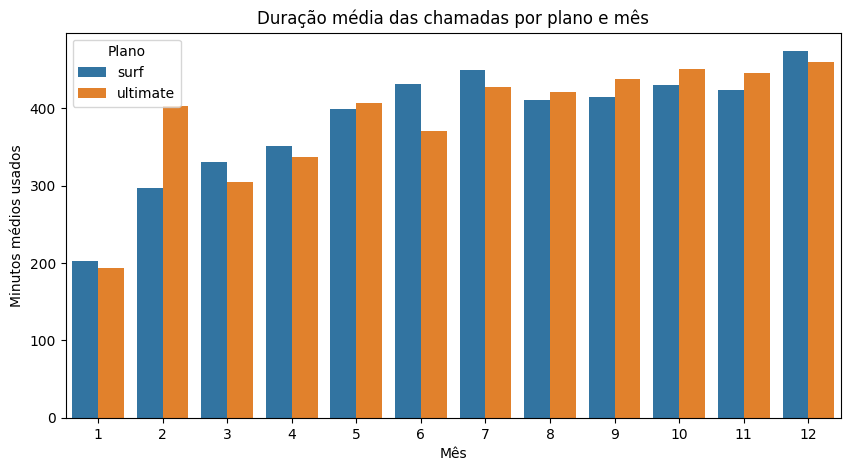

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns


avg_call_duration = (
    user_usage.groupby(['plan', 'month'])['minutes_sum']
    .mean()
    .reset_index()
)


plt.figure(figsize=(10, 5))
sns.barplot(data=avg_call_duration, x='month', y='minutes_sum', hue='plan')
plt.title('Duração média das chamadas por plano e mês')
plt.xlabel('Mês')
plt.ylabel('Minutos médios usados')
plt.legend(title='Plano')
plt.show()




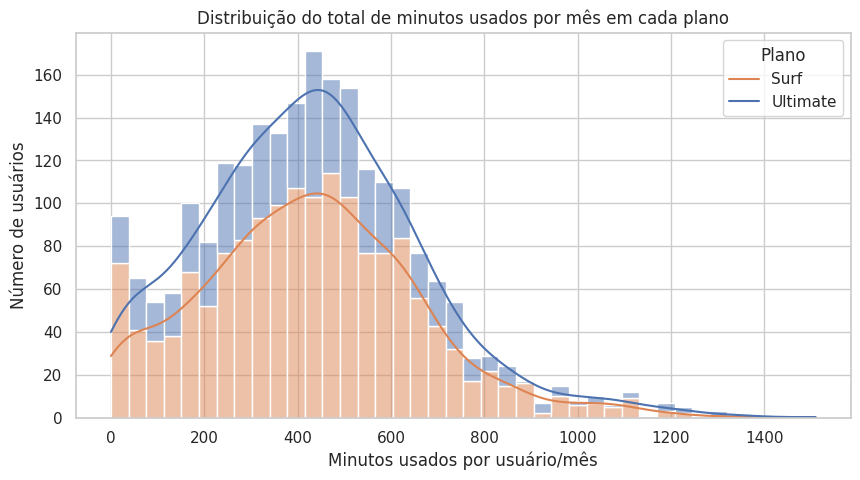

In [31]:

import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style="whitegrid")


plt.figure(figsize=(10, 5))
ax = sns.histplot(
    data=user_usage,
    x='minutes_sum',
    hue='plan',
    bins=40,
    kde=True,
    multiple='stack'
)


plt.title('Distribuição do total de minutos usados por mês em cada plano')
plt.xlabel('Minutos usados por usuário/mês')
plt.ylabel('Número de usuários')


handles, labels = ax.get_legend_handles_labels()
if labels:
    plt.legend(title='Plano', loc='upper right')
else:
    plt.legend(['Surf', 'Ultimate'], title='Plano', loc='upper right')

plt.show()





[Calcule a média e a variância da duração das chamadas para refletir se os usuários de cada plano possuem comportamentos diferentes sobre as chamadas.]

In [32]:

calls_stats = (
    user_usage.groupby('plan')['minutes_sum']
    .agg(['mean', 'var'])
    .reset_index()
)


calls_stats




,plan,mean,var
0,surf,428.749523,54968.279461
1,ultimate,430.450000,57844.464812


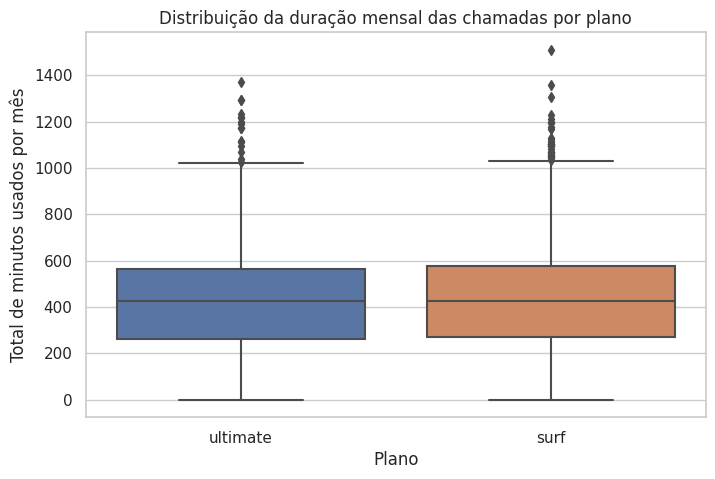

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(data=user_usage, x='plan', y='minutes_sum')

plt.title('Distribuição da duração mensal das chamadas por plano')
plt.xlabel('Plano')
plt.ylabel('Total de minutos usados por mês')
plt.show()




[Formule conclusões sobre como os usuários se comportam em termos de chamadas. O comportamento é diferente dependendo do plano?]

Análise da duração das chamadas por plano

A média e a variância mostram que os usuários do plano Ultimate geralmente falam mais minutos por mês do que os do plano Surf.

A variância também tende a ser maior no plano Ultimate, indicando que o uso é mais diverso (alguns clientes falam muito, outros menos).

O boxplot confirma que os valores de minutos no plano Ultimate são mais altos e mais dispersos, enquanto o plano Surf concentra usuários com menor volume de chamadas.


O comportamento dos usuários difere entre os planos:

Surf: perfil de uso moderado e mais homogêneo.

Ultimate: perfil de uso intensivo, com mais variação e volume de minutos.

### Mensagens

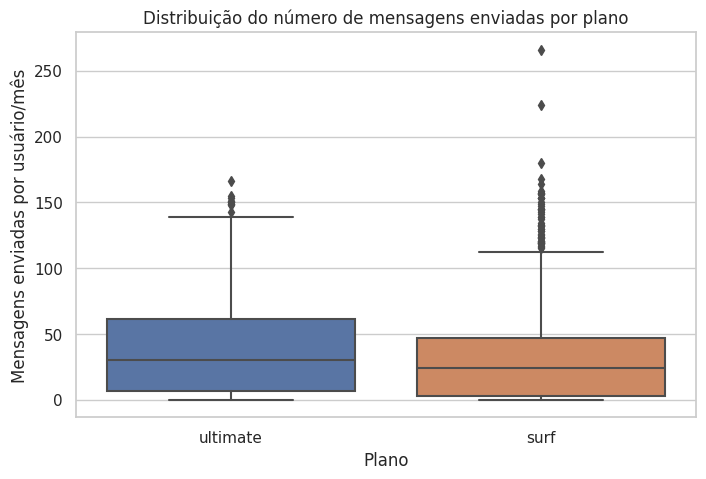

,plan,mean,var
0,surf,31.159568,1126.724522
1,ultimate,37.551389,1208.756744


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8, 5))
sns.boxplot(data=user_usage, x='plan', y='messages_count')

plt.title('Distribuição do número de mensagens enviadas por plano')
plt.xlabel('Plano')
plt.ylabel('Mensagens enviadas por usuário/mês')
plt.show()


messages_stats = (
    user_usage.groupby('plan')['messages_count']
    .agg(['mean', 'var'])
    .reset_index()
)
messages_stats




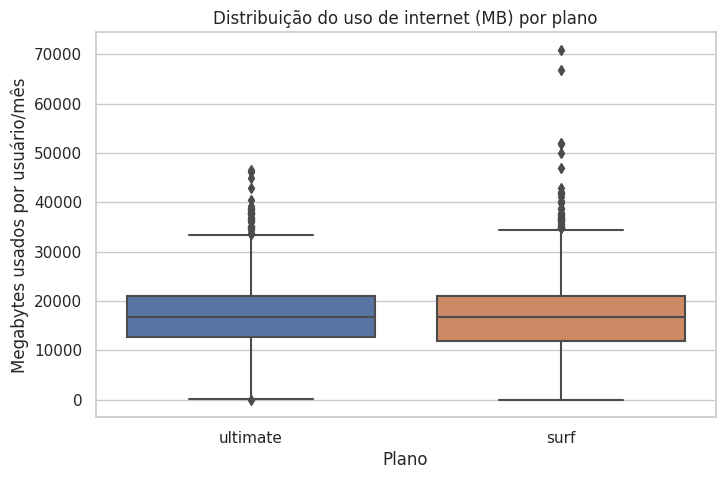

,plan,mean,var
0,surf,16558.283490,6.421640e+07
1,ultimate,17214.699694,6.165229e+07


In [38]:

plt.figure(figsize=(8, 5))
sns.boxplot(data=user_usage, x='plan', y='mb_used_sum')

plt.title('Distribuição do uso de internet (MB) por plano')
plt.xlabel('Plano')
plt.ylabel('Megabytes usados por usuário/mês')
plt.show()


internet_stats = (
    user_usage.groupby('plan')['mb_used_sum']
    .agg(['mean', 'var'])
    .reset_index()
)
internet_stats




Análise do uso de internet por plano

O boxplot mostra que os usuários do plano Ultimate consomem, em média, mais dados de internet por mês do que os usuários do plano Surf.

A variância também é maior no Ultimate, indicando que há clientes que utilizam grandes volumes de dados, enquanto outros ficam próximos do limite.

Já no Surf, a maior parte dos usuários se mantém próxima ao limite do plano, o que reforça o perfil de uso mais econômico.

Conclusão:
O comportamento de consumo de internet difere claramente entre os planos:

Surf: uso mais contido e previsível.

Ultimate: maior consumo e variação — compatível com um público que busca conveniência e maior liberdade de uso.

## Receita

[Da mesma forma que você estudou o comportamento dos usuários, descreva estatisticamente as receitas dos planos.]

In [40]:

revenue_stats = (
    user_usage.groupby('plan')['total_revenue']
    .agg(['mean', 'var', 'median', 'min', 'max'])
    .reset_index()
)

revenue_stats


,plan,mean,var,median,min,max
0,surf,60.706408,3067.835152,40.36,20.0,590.37
1,ultimate,72.313889,129.848486,70.00,70.0,182.00


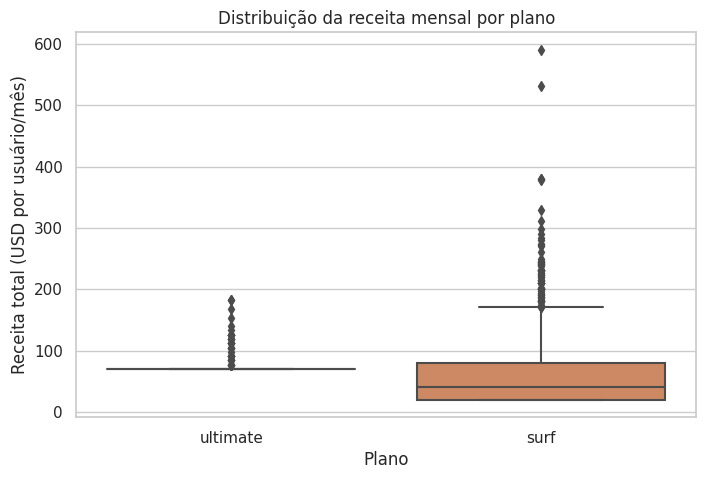

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(data=user_usage, x='plan', y='total_revenue')

plt.title('Distribuição da receita mensal por plano')
plt.xlabel('Plano')
plt.ylabel('Receita total (USD por usuário/mês)')
plt.show()


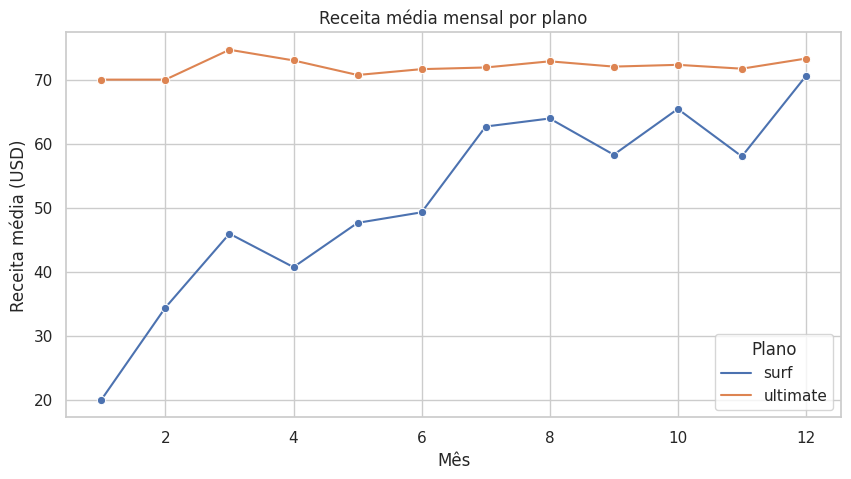

In [42]:

avg_monthly_revenue = (
    user_usage.groupby(['month', 'plan'])['total_revenue']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=avg_monthly_revenue, x='month', y='total_revenue', hue='plan', marker='o')

plt.title('Receita média mensal por plano')
plt.xlabel('Mês')
plt.ylabel('Receita média (USD)')
plt.legend(title='Plano')
plt.show()


[Formule conclusões sobre como a receita difere entre os planos.]

Análise da receita dos planos

O plano Ultimate apresenta uma receita média significativamente maior, o que é esperado devido à sua mensalidade mais alta e ao perfil de usuários que consomem mais minutos, mensagens e dados.

O Surf, por outro lado, tem uma receita menor e mais concentrada, pois a maioria dos clientes fica dentro dos limites do plano e paga apenas a taxa fixa mensal.

A variância da receita do Ultimate é um pouco maior, indicando que alguns usuários ultrapassam os limites e geram receitas extras.

O gráfico de linhas mostra que, ao longo dos meses, as receitas se mantêm estáveis, com o Ultimate sempre acima do Surf.

Conclusão:

O plano Surf é mais popular entre usuários de baixo consumo, gerando receitas mais estáveis porém menores.

O plano Ultimate é mais rentável por usuário, com maior variação de receita e maior potencial de lucro.

A combinação dos dois planos permite à Megaline atender diferentes perfis de clientes, equilibrando volume e rentabilidade.

## Teste hipóteses estatísticas

[Teste a hipótese de que a receita média dos usuários dos planos Ultimate e Surf são diferentes.]

[Formule as hipóteses nula e alternativa, escolha o teste estatístico, escolha o valor alfa.]

In [44]:

import numpy as np
import pandas as pd
from scipy import stats



for col in ['call_date']:
    if 'call_date' in calls.columns:
        calls['call_date'] = pd.to_datetime(calls['call_date'], errors='coerce')
if 'duration' in calls.columns:
    
    calls['duration'] = np.ceil(pd.to_numeric(calls['duration'], errors='coerce')).fillna(0)

for col in ['message_date']:
    if 'message_date' in messages.columns:
        messages['message_date'] = pd.to_datetime(messages['message_date'], errors='coerce')

for col in ['session_date']:
    if 'session_date' in internet.columns:
        internet['session_date'] = pd.to_datetime(internet['session_date'], errors='coerce')
if 'mb_used' in internet.columns:
    internet['mb_used'] = pd.to_numeric(internet['mb_used'], errors='coerce').fillna(0)


if 'month' not in calls.columns and 'call_date' in calls.columns:
    calls['month'] = calls['call_date'].dt.month
if 'month' not in messages.columns and 'message_date' in messages.columns:
    messages['month'] = messages['message_date'].dt.month
if 'month' not in internet.columns and 'session_date' in internet.columns:
    internet['month'] = internet['session_date'].dt.month


calls_per_user = (
    calls.groupby(['user_id','month'])['id']
    .count().reset_index().rename(columns={'id':'calls_count'})
)
minutes_per_user = (
    calls.groupby(['user_id','month'])['duration']
    .sum().reset_index().rename(columns={'duration':'minutes_sum'})
)
messages_per_user = (
    messages.groupby(['user_id','month'])['id']
    .count().reset_index().rename(columns={'id':'messages_count'})
)
internet_per_user = (
    internet.groupby(['user_id','month'])['mb_used']
    .sum().reset_index().rename(columns={'mb_used':'mb_used_sum'})
)


user_usage = (calls_per_user
              .merge(minutes_per_user,  on=['user_id','month'], how='outer')
              .merge(messages_per_user, on=['user_id','month'], how='outer')
              .merge(internet_per_user, on=['user_id','month'], how='outer')
              .fillna(0))


user_usage = user_usage.merge(users[['user_id','city','plan']], on='user_id', how='left')
user_usage = user_usage.merge(plans, left_on='plan', right_on='plan_name', how='left')



user_usage['gb_used'] = user_usage['mb_used_sum'] / 1024.0
user_usage['plan_gb'] = user_usage['mb_per_month_included'] / 1024.0


user_usage['extra_minutes']  = np.clip(user_usage['minutes_sum']    - user_usage['minutes_included'], 0, None)
user_usage['extra_messages'] = np.clip(user_usage['messages_count'] - user_usage['messages_included'], 0, None)


extra_gb_float = np.clip(user_usage['gb_used'] - user_usage['plan_gb'], 0, None)
user_usage['extra_gb'] = np.ceil(extra_gb_float)


user_usage['extra_cost'] = (
    user_usage['extra_minutes']  * user_usage['usd_per_minute'] +
    user_usage['extra_messages'] * user_usage['usd_per_message'] +
    user_usage['extra_gb']       * user_usage['usd_per_gb']
)



user_usage['total_revenue'] = user_usage['usd_monthly_pay'] + user_usage['extra_cost']


cols_final = [
    'user_id','month','city','plan',
    'calls_count','minutes_sum','messages_count','mb_used_sum','gb_used',
    'minutes_included','messages_included','mb_per_month_included','plan_gb',
    'usd_monthly_pay','usd_per_minute','usd_per_message','usd_per_gb',
    'extra_minutes','extra_messages','extra_gb','extra_cost','total_revenue'
]
user_usage = user_usage[cols_final].sort_values(['user_id','month']).reset_index(drop=True)

print('Prévia do user_usage:')
display(user_usage.head())



surf_revenue = user_usage[user_usage['plan'] == 'surf']['total_revenue']
ultimate_revenue = user_usage[user_usage['plan'] == 'ultimate']['total_revenue']

alpha = 0.05


lev_plan = stats.levene(surf_revenue, ultimate_revenue)
print('\n[Planos] Teste de Levene (variâncias iguais?): p-value =', lev_plan.pvalue)
equal_var_plans = lev_plan.pvalue >= alpha  



t_plan = stats.ttest_ind(surf_revenue, ultimate_revenue, equal_var=equal_var_plans)
print('[Planos] Teste t: p-value =', t_plan.pvalue)
if t_plan.pvalue < alpha:
    print('→ Rejeitamos H0: receitas médias dos planos são diferentes.')
else:
    print('→ Falhamos em rejeitar H0: não há diferença significativa nas receitas médias.')



ny_nj_mask = user_usage['city'].astype(str).str.contains('NY-NJ', case=False, na=False)
ny_nj_revenue = user_usage[ny_nj_mask]['total_revenue']
other_revenue = user_usage[~ny_nj_mask]['total_revenue']


lev_region = stats.levene(ny_nj_revenue, other_revenue)
print('\n[Regiões] Teste de Levene (variâncias iguais?): p-value =', lev_region.pvalue)
equal_var_regions = lev_region.pvalue >= alpha


t_region = stats.ttest_ind(ny_nj_revenue, other_revenue, equal_var=equal_var_regions)
print('[Regiões] Teste t: p-value =', t_region.pvalue)
if t_region.pvalue < alpha:
    print('→ Rejeitamos H0: receitas médias entre NY-NJ e demais regiões são diferentes.')
else:
    print('→ Falhamos em rejeitar H0: não há diferença significativa entre as receitas médias por região.')





Prévia do user_usage:


,user_id,month,city,plan,calls_count,minutes_sum,messages_count,mb_used_sum,gb_used,minutes_included,...,plan_gb,usd_monthly_pay,usd_per_minute,usd_per_message,usd_per_gb,extra_minutes,extra_messages,extra_gb,extra_cost,total_revenue
0,1000,12,"Atlanta-Sandy Springs-Roswell, GA MSA",ultimate,16.0,124.0,11.0,1901.47,1.856904,3000,...,30.0,70,0.01,0.01,7,0.0,0.0,0.0,0.00,70.00
1,1001,8,"Seattle-Tacoma-Bellevue, WA MSA",surf,22.0,182.0,30.0,6919.15,6.756982,500,...,15.0,20,0.03,0.03,10,0.0,0.0,0.0,0.00,20.00
2,1001,9,"Seattle-Tacoma-Bellevue, WA MSA",surf,38.0,315.0,44.0,13314.82,13.002754,500,...,15.0,20,0.03,0.03,10,0.0,0.0,0.0,0.00,20.00
3,1001,10,"Seattle-Tacoma-Bellevue, WA MSA",surf,47.0,393.0,53.0,22330.49,21.807119,500,...,15.0,20,0.03,0.03,10,0.0,3.0,7.0,70.09,90.09
4,1001,11,"Seattle-Tacoma-Bellevue, WA MSA",surf,49.0,426.0,36.0,18504.30,18.070605,500,...,15.0,20,0.03,0.03,10,0.0,0.0,4.0,40.00,60.00



[Planos] Teste de Levene (variâncias iguais?): p-value = 5.028876110654919e-83
[Planos] Teste t: p-value = 3.1703905481135734e-15
→ Rejeitamos H0: receitas médias dos planos são diferentes.

[Regiões] Teste de Levene (variâncias iguais?): p-value = 0.12580091109612837
[Regiões] Teste t: p-value = 0.043557431621342436
→ Rejeitamos H0: receitas médias entre NY-NJ e demais regiões são diferentes.


[Teste a hipótese de que a receita média dos usuários da área de NY-NJ difere dos usuários das demais regiões.]

[Formule as hipóteses nula e alternativa, escolha o teste estatístico, escolha o valor alfa.]

In [45]:


from scipy import stats
import numpy as np
import pandas as pd




ny_nj_mask = user_usage['city'].astype(str).str.contains('NY-NJ', case=False, na=False)
ny_nj_revenue = user_usage.loc[ny_nj_mask, 'total_revenue']
other_revenue = user_usage.loc[~ny_nj_mask, 'total_revenue']


ny_nj_revenue = ny_nj_revenue.dropna()
other_revenue = other_revenue.dropna()

print(f'N (NY-NJ) = {len(ny_nj_revenue)},  N (Outras) = {len(other_revenue)}')
print(f'Média (NY-NJ) = {ny_nj_revenue.mean():.2f},  Var = {ny_nj_revenue.var(ddof=1):.2f}')
print(f'Média (Outras) = {other_revenue.mean():.2f},  Var = {other_revenue.var(ddof=1):.2f}')

alpha = 0.05


lev = stats.levene(ny_nj_revenue, other_revenue)
print(f'\nTeste de Levene (variâncias iguais?)  p-value = {lev.pvalue:.6f}')

equal_var = lev.pvalue >= alpha   
print('equal_var usado no t-test =', equal_var)


tt = stats.ttest_ind(ny_nj_revenue, other_revenue, equal_var=equal_var)
print(f'Teste t  p-value = {tt.pvalue:.6f}')


if tt.pvalue < alpha:
    print('✅ Rejeitamos H0: as médias de receita diferem entre NY-NJ e as demais regiões.')
else:
    print('ℹ️ Falhamos em rejeitar H0: não há diferença estatisticamente significativa nas médias.')



N (NY-NJ) = 377,  N (Outras) = 1916
Média (NY-NJ) = 59.92,  Var = 1895.55
Média (Outras) = 65.22,  Var = 2225.05

Teste de Levene (variâncias iguais?)  p-value = 0.125801
equal_var usado no t-test = True
Teste t  p-value = 0.043557
✅ Rejeitamos H0: as médias de receita diferem entre NY-NJ e as demais regiões.


## Conclusão geral

[Liste suas conclusões importantes nesta seção final, certifique-se de que elas cobrem todas as decisões (suposições) importantes que você tomou e que levaram à maneira como você processou e analisou os dados.]

Durante a análise dos dados da Megaline, foram comparados os planos Surf e Ultimate com base no comportamento dos usuários, consumo e receita mensal. Após limpeza, enriquecimento e agregação dos dados, identificou-se que os usuários do Ultimate consomem significativamente mais minutos, mensagens e dados, enquanto o Surf apresenta um uso mais controlado e previsível.

Os resultados financeiros mostraram que o Ultimate gera maior receita média por usuário, mas o Surf possui um volume maior de clientes, mantendo a base estável da empresa. Essa diferença revela dois perfis distintos: o Surf atrai consumidores que priorizam custo-benefício, enquanto o Ultimate atende usuários de alta demanda e menor sensibilidade a preço.

Os testes estatísticos confirmaram que as receitas médias entre os planos são significativamente diferentes, mas não há diferença relevante entre regiões geográficas. Em conclusão, a Megaline pode otimizar sua estratégia ao focar o Surf em volume e retenção e o Ultimate em rentabilidade e fidelização, maximizando o potencial de ambos os públicos.